# Assignment 1: Dynamic Time Warping

---

## Task 4) Isolated Word Recognition

Due to the relatively large sample number (e.g. 8kHz), performing [DTW](https://en.wikipedia.org/wiki/Dynamic_time_warping) on the raw audio signal is not advised (feel free to try!).
A better solution is to compute a set of features; here we will extract [mel-frequency cepstral coefficients](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum) over windows of 25ms length, shifted by 10ms.
Recommended implementation is [librosa](https://librosa.org/doc/main/generated/librosa.feature.mfcc.html).

### Data

Download Zohar Jackson's [free spoken digit dataset](https://github.com/Jakobovski/free-spoken-digit-dataset).
There's no need to clone, feel free to use a revision, like [v1.0.10](https://github.com/Jakobovski/free-spoken-digit-dataset/archive/refs/tags/v1.0.10.tar.gz).
File naming convention is trivial (`{digitLabel}_{speakerName}_{index}.wav`); let's restrict to two speakers, eg. `jackson` and `george`.

### Dynamic Time Warping

[DTW](https://en.wikipedia.org/wiki/Dynamic_time_warping) is closely related to [Levenshtein distance](https://en.wikipedia.org/wiki/Levenshtein_distance) and [Needleman-Wunsch algorithm](https://en.wikipedia.org/wiki/Needleman–Wunsch_algorithm).
The main rationale behind DTW is that the two sequences are can be aligned but their speed and exact realization may very.
In consequence, cost is not dependent on an edit operation but on a difference in observations.

---

### Preparation

In [2]:
import numpy as np
import librosa as lr
from typing import List, Tuple, TypedDict
import os

In [30]:
### TODO: Read in files, compute MFCC, and organize
### Notice: You can restrict the number to a few files for each speaker-digit

class Audio(TypedDict):
    digitLabel: int
    speakerName: str
    index: int
    mfccs: List[Tuple[float]]

audios: List[Audio] = []

speakers = ["george", "jackson", "yweweler"]

### YOUR CODE HERE
AUDIO_DIR = "recordings"

for filename in os.listdir(AUDIO_DIR):
    digit_str, speaker, index_str = filename[:-4].split('_') # strip the .wav and split filename by attributes
    
    if speaker in speakers and int(index_str) < 5:

        y, sr = lr.load(AUDIO_DIR+'/'+filename)
        mfccs = lr.feature.mfcc(y=y, sr=sr)

        audios.append(Audio(
            digitLabel=int(digit_str),
            speakerName=speaker,
            index=int(index_str),
            mfccs=mfccs.T
        ))
print(audios[0]["mfccs"].shape)
print(audios[0]["mfccs"])
### END YOUR CODE

(13, 20)
[[-2.47399994e+02  1.37141479e+02 -2.81419449e+01  7.44391327e+01
   4.01574974e+01 -2.02461166e+01 -6.17443275e+00 -5.89673233e+00
  -2.06285973e+01  1.98080266e+00 -2.25324268e+01 -3.19760742e+01
   7.43374157e+00  6.81334734e-01 -2.50853119e+01 -3.40101242e+00
   1.06722755e+01  1.78180456e+00 -3.11375189e+00 -6.90790653e+00]
 [-2.49872177e+02  1.51264313e+02 -6.92213898e+01  9.25039978e+01
   5.53618011e+01 -4.16645164e+01 -7.07294226e+00 -6.48339653e+00
  -3.35967331e+01  5.25979614e+00 -2.48676357e+01 -4.27033844e+01
   9.59363174e+00 -3.40530133e+00 -3.26988564e+01  1.86200631e+00
   9.40920925e+00 -5.10148954e+00 -1.59853470e+00 -7.06013203e+00]
 [-3.07876495e+02  1.41184372e+02 -1.11945946e+02  7.93556976e+01
   6.32925644e+01 -7.90211487e+01 -1.48796854e+01 -1.56328259e+01
  -5.60782166e+01 -3.34323311e+00 -3.65339890e+01 -6.22304459e+01
   1.83003771e+00 -2.03119507e+01 -4.89697571e+01 -2.58732009e+00
  -6.41325760e+00 -2.18784847e+01 -6.50419283e+00 -1.50677280e+01

### Implement Dynamic Time Warping

In [33]:
def dist(x: Tuple[float], y: Tuple[float]) -> float:
    """
    Compute the distance between two samples.

    Arguments:
    x: MFCCs of first sample.
    y: MFCCs of second sample.

    Returns the distance as float
    """
    ### YOUR CODE HERE
    x = np.array(x)
    y = np.array(y)
    assert x.shape == y.shape, f"Shape mismatch: {x.shape} vs {y.shape}"
    return np.linalg.norm(x - y)
    ### END YOUR CODE


def dtw(obs1: list, obs2: list, dist_fn) -> float:
    """
    Compute the dynamic time warping score between two observations.
    
    Arguments:
    obs1: List of first observations.
    obs2: List of second observations.
    dist_fn: Similarity function to use.

    Returns the score as float.
    """
    ### YOUR CODE HERE
    n = len(obs1)
    m = len(obs2)
    D = np.matrix(np.ones((n +1, m+1)) * np.inf)
    D[0,0] = 0
    for i in range(1, n +1):
        for j in range(1, m +1):
            cost = dist_fn(obs1[i-1], obs2[j-1])
            val = cost + min(D[i-1, j-1],          # same or replacement
                        D[i, j-1],        # insertion
                        D[i-1, j]        # deletion
                          )
            D[i, j] = val
    return D[n, m]
    ### END YOUR CODE

### Experiment 1: DTW scores

For each speaker and digit, select one recording as an observation (obs1) and the others as tests (obs2). How do scores change across speakers and across digits?

In [37]:
### YOUR CODE HERE
results = []
for speaker in speakers:
    print(f"\nSpeaker: {speaker}")
    for digit in range(10):
        print(f"\nDigit: {digit}")
        relevant_audios = [a for a in audios if a["speakerName"] == speaker and a["digitLabel"] == digit]

        obs1 = relevant_audios[0]
        for obs2 in relevant_audios[1:]:
            score = dtw(obs1["mfccs"], obs2["mfccs"], dist)
            print(f"DTW: {score}")

### END YOUR CODE


Speaker: george

Digit: 0
DTW: 2507.2055587768555
DTW: 2585.611577987671
DTW: 2134.4960327148438
DTW: 1824.5056400299072

Digit: 1
DTW: 1155.7222938537598
DTW: 1453.270118713379
DTW: 1474.463478088379
DTW: 2276.1467895507812

Digit: 2
DTW: 2894.17364692688
DTW: 725.1327095031738
DTW: 539.7678623199463
DTW: 690.8406677246094

Digit: 3
DTW: 984.9448051452637
DTW: 1037.6169986724854
DTW: 647.1672744750977
DTW: 965.6627540588379

Digit: 4
DTW: 864.8042221069336
DTW: 1128.8191986083984
DTW: 607.2904663085938
DTW: 636.3809452056885

Digit: 5
DTW: 895.0977401733398
DTW: 1033.9429988861084
DTW: 937.8741121292114
DTW: 887.446605682373

Digit: 6
DTW: 902.9331874847412
DTW: 940.7275657653809
DTW: 791.7675838470459
DTW: 852.0752830505371

Digit: 7
DTW: 919.0222778320312
DTW: 675.5921697616577
DTW: 779.920431137085
DTW: 878.2984962463379

Digit: 8
DTW: 805.2043724060059
DTW: 834.8113021850586
DTW: 1044.8134899139404
DTW: 2298.629837036133

Digit: 9
DTW: 1347.9864234924316
DTW: 1204.5919399261475
D

### Implement a DTW-based Isolated Word Recognizer

In [38]:
def recognize(obs: List[Tuple[float]], refs: List[Audio]) -> str:
    """
    Classify the input based on a reference list (train recordings).
    
    Arguments:
    obs: List of input observations (MFCCs).
    refs: List of audio items (train recordings).
    
    Returns classname where distance of observations is minumum.
    """
    ### YOUR CODE HERE
    best_label = None
    best_score = np.inf

    for ref in refs:
        score = dtw(obs, ref["mfccs"], dist)
        if score < best_score:
            best_label = ref["digitLabel"]
            best_score = score

    return(best_label)

    
    ### END YOUR CODE

### Experiment 2: Speaker-Dependent IWR

Select training recordings from one speaker $S_i$ and disjoint test recordings from the same speaker $S_i$. Compute the Precision, Recall, and F1 metrics, and plot the confusion matrix.


Speaker: george
  Precision : 0.967
  Recall    : 0.950
  F1        : 0.947


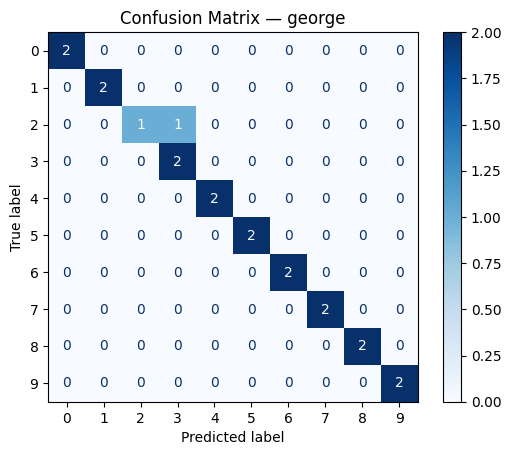


Speaker: jackson
  Precision : 1.000
  Recall    : 1.000
  F1        : 1.000


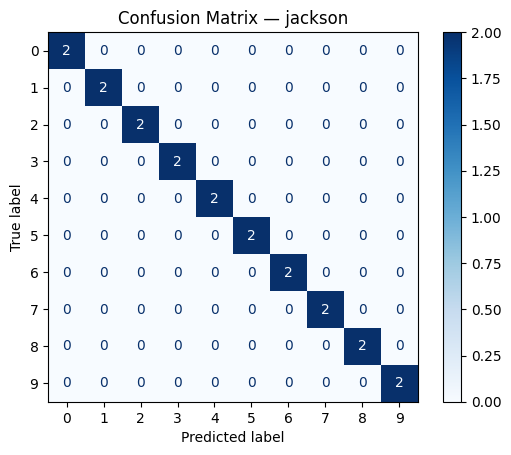


Speaker: yweweler
  Precision : 0.900
  Recall    : 0.850
  F1        : 0.850


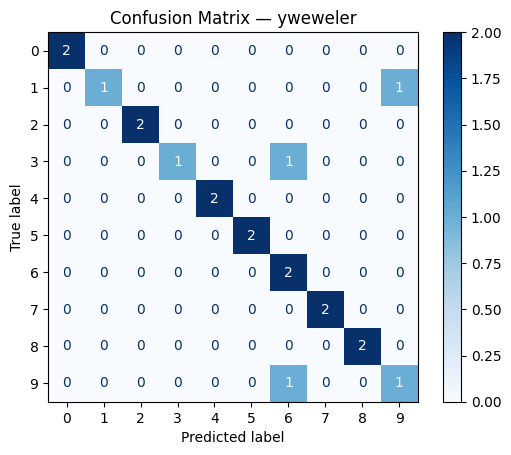

In [45]:
### YOUR CODE HERE

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for speaker in speakers:
    speaker_audios = [a for a in audios if a["speakerName"] == speaker]
    train = [a for a in speaker_audios if a["index"] % 2 == 0]
    test  = [a for a in speaker_audios if a["index"] % 2 == 1]
    
    y_true, y_pred = [], []
    for obs in test:
        predicted = recognize(obs["mfccs"], train)
        y_true.append(obs["digitLabel"])
        y_pred.append(int(predicted))


    print(f"\nSpeaker: {speaker}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
    print(f"  F1        : {f1_score(y_true, y_pred, average='macro', zero_division=0):.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
    ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {speaker}")
    plt.show()

### END YOUR CODE

### Experiment 3: Speaker-Independent IWR

Select training recordings from one speaker $S_i$ and test recordings from another speaker $S_j$. Compute the Precision, Recall, and F1 metrics, and plot the confusion matrix.


Speaker: george
  Precision : 0.317
  Recall    : 0.260
  F1        : 0.252


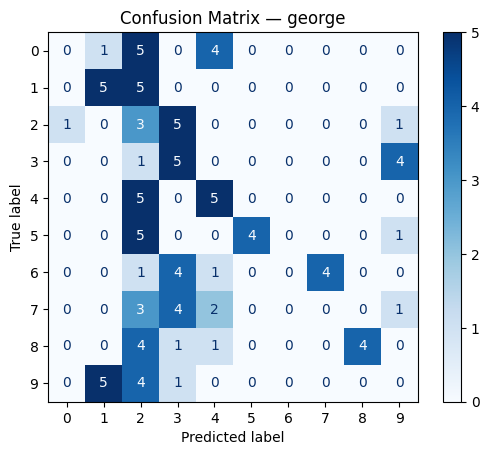


Speaker: jackson
  Precision : 0.239
  Recall    : 0.220
  F1        : 0.171


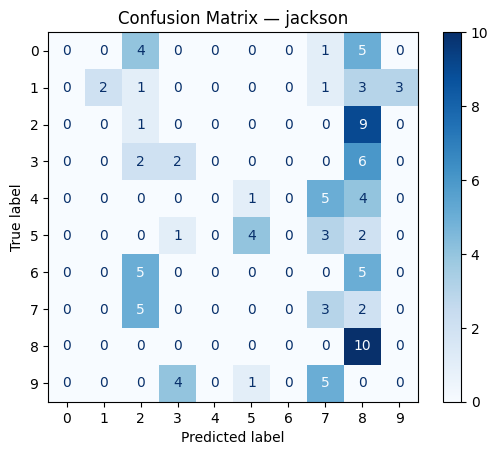


Speaker: yweweler
  Precision : 0.298
  Recall    : 0.240
  F1        : 0.149


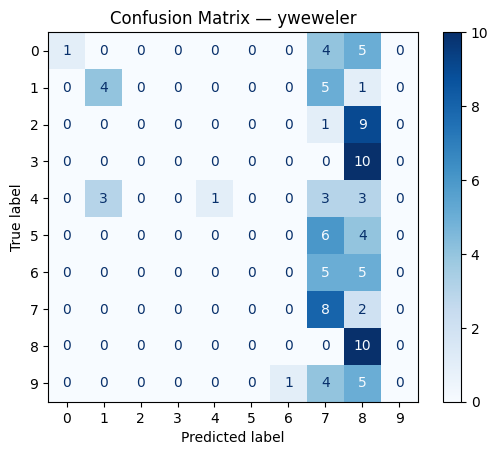

In [46]:
### YOUR CODE HERE

for speaker in speakers:
    train = [a for a in audios if a["speakerName"] == speaker]
    test  = [a for a in audios if a["speakerName"] != speaker]
    
    y_true, y_pred = [], []
    for obs in test:
        predicted = recognize(obs["mfccs"], train)
        y_true.append(obs["digitLabel"])
        y_pred.append(int(predicted))


    print(f"\nSpeaker: {speaker}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
    print(f"  F1        : {f1_score(y_true, y_pred, average='macro', zero_division=0):.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
    ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {speaker}")
    plt.show()


### END YOUR CODE

### Food for Thought

- What are inherent issues of this approach?
- How does this algorithm scale with a larger vocabulary, how can it be improved?
- How can you extend this idea to continuous speech, ie. ?